# Time evolution of $\mathrm{Yb}$ spin-orbit coupled system with 2-body loss

- Units
    - $\hbar=1.0545\times 10^{-34} \,\mathrm{J}\cdot\mathrm{s}$
    - $E_r/\hbar = 8.8593 \,\mathrm{kHz}$
    - $k_r = \sin\left(\frac{\theta}{2}\right)\frac{2\pi}{556 \,\mathrm{nm}} = 6.9462\times10^6 \, \mathrm{m}^{-1}$

Where $\theta=75.854^\circ$
  
- Derived Units
    - $t_r = \hbar/E_r = 0.1129 \,\mathrm{ms}$
    - $m_r = \hbar^2 k_r^2 / 2 E_r = m_{\mathrm{Yb}} = 2.872×10^{-25} \, \mathrm{kg}$

- Hamiltonians

$$
\begin{equation}
    H_{\text{free}}=\sum_{q_x, \sigma} \frac{\hbar^2 q_x^2}{2m_\mathrm{Yb}}c_{\sigma}^\dagger(q_x) c_{\sigma}(q_x)
\end{equation}
$$

$$
\begin{equation}
    H_{\text{loss}}=-\frac{1}{L}\frac{i}{2}\gamma\sum_{k, k', q}c_\downarrow^\dagger(k'+q)c_\uparrow^\dagger(k-q)c_\uparrow(k)c_\downarrow(k')
\end{equation}
$$

$q_x=[-k_{\text{cutoff}}, ..., 2k_0, -k_0, 0, k_0, 2k_0, ..., k_{\text{cutoff}}]$ where $k_0 = \frac{2\pi}{L}$

- parameters
  - $\hbar/\hbar = 1$
  - $k_r/k_r = 1$
  - $m_{\mathrm{Yb}}/m_r = 1$
  - $\gamma/E_r =\ ?$
  - $T_2 = \ ?$


- basis
  
$$\mathcal{B}= \{c_{\sigma_1}^\dagger(k_1)c_{\sigma_2}^\dagger(k_2)\cdots c_{\sigma_n}^\dagger(k_n)\ket{0}:\sigma_j=\uparrow,\downarrow, k_1<k_2<\cdots<k_n, |k_j|<k_\text{cutoff}, k_j\in (2\pi / L) \mathbb Z\}$$
$$[H]_{\mathcal{B}}$$

In [3]:
# !unzip opalg

imports

In [ ]:
import json
import os
import itertools

import numpy as np
import scipy

import tqdm
import matplotlib.pyplot as plt

from quant_mech import hilbert, ybsoc


drive mount & save data path

In [5]:
# from google.colab import drive
# drive.mount('/content/drive')

In [6]:
DATA_ROOT = r"C:\workspace\yb-soc-two-body-loss\data\numerical\test\0"
os.makedirs(DATA_ROOT, exist_ok=True)

## System Definition

In [7]:
t_r = 0.1129 # ms

In [ ]:
n_momentum_points = 13
n_particles = 5

hbar = 1.
m_Yb = 1.

k0 = 0.5
L = 2 * np.pi / k0
gamma = 0.36

T2 = 0.52 / t_r

hilb = hilbert.PBCBox1D(
    L=L,
    n_momentum_points=n_momentum_points,
    n_particle=n_particles
)

## Initial State Preparation

In [9]:
ks = np.array(system.momentums)
momentum_modes = tuple(np.argsort(ks ** 2)[:n_particles].tolist())
pure = system.get_momentum_eigenstate(
    tuple((mode, 1) for mode in momentum_modes)
)

mixture = system.get_momentum_eigenstate(
    tuple((mode, (-1) ** idx) for idx, mode in enumerate(momentum_modes))
)

prob_up = 1 - 0.31844
theta = 2 * np.arccos(np.sqrt(prob_up))  # p(up) = 2/3, p(down) = 1/3
phi = 0

alpha = np.cos(theta / 2)
beta = np.exp(1j * phi) * np.sin(theta / 2)

spin_amps = {
    1: alpha,
    -1: beta
}
spins = list(spin_amps.keys())

superposed = np.zeros_like(mixture)
for spin_config in itertools.product(spins, repeat=n_particles):
    amp = np.prod([spin_amps[s] for s in spin_config])
    basis_config = tuple(
        (mode, spin) for mode, spin in zip(momentum_modes, spin_config)
    )
    basis = system.get_momentum_eigenstate(basis_config)
    superposed = superposed + amp * basis

### plot utils

In [10]:
def plot_numbers(up_nums, down_nums, tick_labels=None, title=None, save_path=None, save_options=None):
    total_nums = up_nums + down_nums
    L = total_nums.shape[0]
    indices = np.arange(L) - (L // 2 - 1)
    
    bar_width = ((6 - 1) / L) * 1.0 / 2
    
    plt.figure(figsize=(6, 4))
    
    plt.bar(indices, total_nums, width=2*bar_width, alpha=0.2, color='green')
    plt.bar(indices - bar_width/2, up_nums, bar_width, label='up')
    plt.bar(indices + bar_width/2, down_nums, bar_width, label='down')
    
    if tick_labels is not None:
        plt.xticks(indices, tick_labels)
    else:
        plt.xticks(indices)
    if title is not None:
        plt.title(title)
    else:
        plt.title("Expected numbers")
    plt.ylabel('$\\langle n\\rangle$')
    plt.legend()
    if save_path is not None:
        if save_options is not None:
            plt.savefig(save_path, **save_options)
        else:
            plt.savefig(save_path)
    plt.show()

def generate_k_labels(n_momentum_points, k0, ):
    zero_index = -((n_momentum_points - 1) // 2)
    start_coeff = zero_index * k0
    coeffs = [start_coeff + i * k0 for i in range(n_momentum_points)]
    result_list = []
    for c in coeffs:
        if c == 0:
            # 계수가 0일 경우
            formatted_str = "$0$"
        elif c == 1:
            # 계수가 1일 경우
            formatted_str = "$k_r$"
        elif c == -1:
            # 계수가 -1일 경우
            formatted_str = "$-k_r$"
        else:
            # 그 외의 경우 (정수 및 실수)
            # 계수가 2.0, -3.0과 같이 정수이면 소수점(.0)을 제거합니다.
            if c == int(c):
                num_str = str(int(c))
            else:
                num_str = str(c)
            formatted_str = f"${num_str}k_r$"
        result_list.append(formatted_str)
    return result_list
k_tick_labels = generate_k_labels(n_momentum_points, k0)

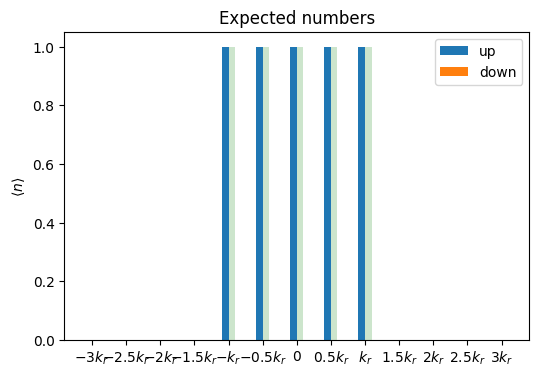

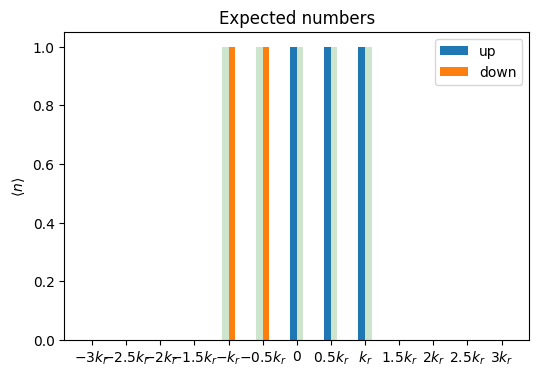

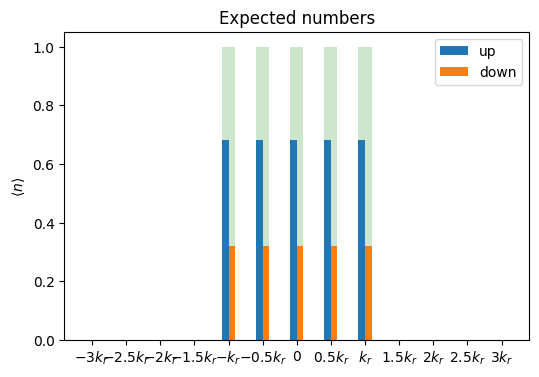

In [11]:
pure_numbers_up, pure_numbers_down = system.momentum_expected_numbers(pure)
plot_numbers(pure_numbers_up, pure_numbers_down, tick_labels=k_tick_labels)

pure_numbers_up, pure_numbers_down = system.momentum_expected_numbers(mixture)
plot_numbers(pure_numbers_up, pure_numbers_down, tick_labels=k_tick_labels)

pure_numbers_up, pure_numbers_down = system.momentum_expected_numbers(superposed)
plot_numbers(pure_numbers_up, pure_numbers_down, tick_labels=k_tick_labels)

In [12]:
# initial_state = pure
# initial_state = mixture
initial_state = superposed

## coherent simulation

- Schrodinger equation:
\begin{equation}
    \frac{d}{dt}\ket{\psi} = -\frac{i}{\hbar}(H_\text{free} + H_\text{loss})\ket{\psi}
\end{equation}

### Simulation settings

In [13]:
t0 = 0
t1 = 2.0 / t_r
n_timesteps = 101
save_at = np.linspace(t0, t1, n_timesteps)
step_size = save_at[1] - save_at[0]

In [14]:
hamiltonian = pa_system.sparse_hamiltonian_scipy_csr()

In [15]:
result = scipy.sparse.linalg.expm_multiply(
    -1j * hamiltonian / hbar,
    initial_state,
    start=t0,
    stop=t1,
    num=n_timesteps,
    endpoint=True,
)

psis = result

In [16]:
total_up = np.zeros((save_at.size,))
total_down = np.zeros((save_at.size,))

for i in range(save_at.size):
    ups, downs = system.momentum_expected_numbers(psis[i])
    total_up[i] = np.sum(ups)
    total_down[i] = np.sum(downs)

total_up /= system.n_particle
total_down /= system.n_particle

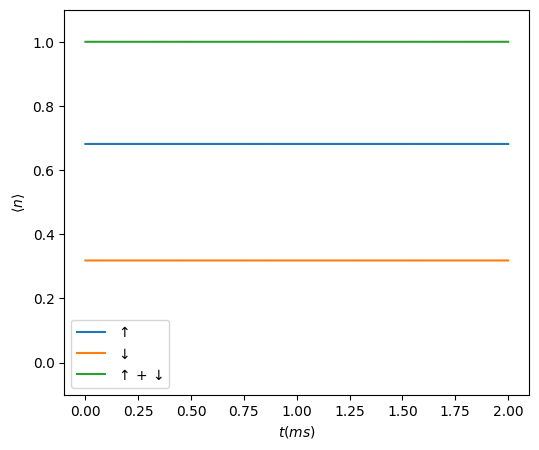

In [17]:
plt.figure(figsize=(6, 5))
t = save_at * 0.1129

plt.plot(t, total_up, label="$\\uparrow$")
plt.plot(t, total_down, label="$\\downarrow$")
plt.plot(t, total_up + total_down, label="$\\uparrow + \\downarrow$")

plt.ylabel("$\\langle n \\rangle$")
plt.xlabel("$t (ms)$")
plt.ylim(-0.1, 1.1)

plt.legend()
plt.show()

## Decoherence simulation by Quantum Jump method

\begin{align}
\frac{d\rho}{dt}&=-\frac{i}{\hbar}\left[H\rho-\rho H^\dagger\right]-\operatorname{off-diagonal}(\rho)/T_2 \\
&=-\frac{i}{\hbar}[H_\text{free}, \rho] -\frac{1}{2}\{2\Gamma/
\hbar, \rho\}-\sum_{k=1}^{\dim\mathcal H}\left[L_k\rho L_k^\dagger-\frac{1}{2}\{L_k^\dagger L_k,\rho\}\right]
\end{align}
Where $\Gamma=iH_\text{loss}$, $L_k=\sqrt{\frac{1}{T_2}}\ket{k}\bra{k}$

- $T_2 = 0.4 \,\mathrm{ms}$

### simulation settings

In [18]:
t0 = 0
t1 = 2.0 / 0.1129
n_timesteps = 51
save_at = np.linspace(t0, t1, n_timesteps)
step_size = save_at[1] - save_at[0]

n_trajectories = 128
batch_size = 32
jumps_per_step = 2 # total 100 tries to jump

assert n_trajectories % batch_size == 0

In [19]:
num_batches = n_trajectories // batch_size
total_n_steps = (n_timesteps - 1) * jumps_per_step
delta_t = (t1 - t0) / total_n_steps
loss_op = 1j * pa_system.sparse_hamiltonian_scipy_csr(kinetic=False, interaction=True) # \Gamma = iH_{\loss}
hilb_dim = system.space_dim
H_eff = pa_system.sparse_hamiltonian_scipy_csr() - (1j * hbar) / (2 * T2) * scipy.sparse.identity(hilb_dim, format='csr')

In [20]:
up_nums_momentum = np.zeros((n_timesteps, n_momentum_points))
down_nums_momentum = np.zeros((n_timesteps, n_momentum_points))
# n_position_points = n_momentum_points
# up_nums_position = np.zeros((n_timesteps, n_position_points))
# down_nums_position = np.zeros((n_timesteps, n_position_points))

for i_batch in range(num_batches):
    psi_batched = np.repeat(initial_state[:, np.newaxis], batch_size, axis=1) # prepare batched states
    mask = np.full((batch_size,), 1.)
    zeros = np.zeros((batch_size,))
    
    psis = psi_batched.T # (n, b) => (b, n)
    up_mom, down_mom = system.momentum_expected_numbers_vectorized(psis) # (b, L)
    up_nums_momentum[0, :] += np.sum(up_mom * mask[:, np.newaxis], axis=0)
    down_nums_momentum[0, :] += np.sum(down_mom * mask[:, np.newaxis], axis=0)
    # up_pos, down_pos = system.position_expected_numbers_vectorized(psis)
    # up_nums_position[0, :] += np.sum(up_pos * mask[:, np.newaxis], axis=0)
    # down_nums_position[0, :] += np.sum(down_pos * mask[:, np.newaxis], axis=0)
    
    for iteration in tqdm.trange(total_n_steps, desc=f"batch {i_batch}: {(i_batch+1) * batch_size}/{n_trajectories} Trajectories", leave=False):
        # evolution
        psi_batched = scipy.sparse.linalg.expm_multiply(
            -1j * H_eff * delta_t / hbar,
            psi_batched
        )
        # calculate jump probabilities
        expectation = np.einsum("ib,ib->b", psi_batched.conj(), loss_op @ psi_batched)
        loss_probs = (2 / hbar) * expectation * delta_t              # (n, b)
        jump_probs = (1 / T2) * (np.abs(psi_batched) ** 2) * delta_t # (n, b)
        
        # for loss term
        mask = np.where(np.random.rand(batch_size,) < loss_probs, zeros, mask) # discard the trajectory if loss jump is occurred.
        
        # calc probs
        prob_keep_original = 1.0 - np.sum(jump_probs, axis=0)    # (b,)
        full_probs = np.vstack([jump_probs, prob_keep_original]) # (n + 1, b)
        cum_probs = np.cumsum(full_probs, axis=0)                # (n + 1, b)
        random_values = np.random.rand(1, batch_size)
        chosen_indices = np.argmax(cum_probs > random_values, axis=0)

        # apply jump
        mask_to_change = chosen_indices < hilb_dim
        cols_to_change = np.arange(batch_size)[mask_to_change]
        if cols_to_change.size > 0:
            rows_for_one_hot = chosen_indices[mask_to_change]
            psi_batched[:, cols_to_change] = 0
            psi_batched[rows_for_one_hot, cols_to_change] = 1
            
        # normalize for not jumped states:
        psi_batched[:, chosen_indices == hilb_dim] /= np.linalg.norm(psi_batched[:, chosen_indices == hilb_dim], axis=0)
        
        # calculate obaservables
        if (iteration + 1) % jumps_per_step != 0:
            continue
        
        i = (iteration + 1) // jumps_per_step
        psis = psi_batched.T # (n, b) => (b, n)
        
        up_mom, down_mom = system.momentum_expected_numbers_vectorized(psis) # (b, L)
        up_nums_momentum[i, :] += np.sum(up_mom * mask[:, np.newaxis], axis=0)
        down_nums_momentum[i, :] += np.sum(down_mom * mask[:, np.newaxis], axis=0)
        
        # if i < n_timesteps - 1:
        #     continue
        
        # up_pos, down_pos = system.position_expected_numbers_vectorized(psis)
        # up_nums_position[i, :] += np.sum(up_pos * mask[:, np.newaxis], axis=0)
        # down_nums_position[i, :] += np.sum(down_pos * mask[:, np.newaxis], axis=0)

up_nums_momentum /= n_trajectories
down_nums_momentum /= n_trajectories
# up_nums_position /= n_trajectories
# down_nums_position /= n_trajectories

## plot & save

In [21]:
data_dir = os.path.join(DATA_ROOT, "data")
figs_dir = os.path.join(DATA_ROOT, "figs")

os.makedirs(data_dir, exist_ok=True)
os.makedirs(figs_dir, exist_ok=True)

In [22]:
np.save(os.path.join(data_dir, "t.npy"), save_at)
np.save(os.path.join(data_dir, "up_no_decoherence.npy"), total_up)
np.save(os.path.join(data_dir, "down_no_decoherence.npy"), total_down)
np.save(os.path.join(data_dir, "up_decoherence.npy"), total_up_decoherence)
np.save(os.path.join(data_dir, "down_decoherence.npy"), total_down_decoherence)

with open(os.path.join(data_dir, "metadata.json"), "w+") as f:
    json.dump({
    "d": system.d,
    "lengths": system.lengths,
    "n_particle": system.n_particle,
    "hbar": system.hbar,
    "q": system.q.item(),
    "m_Yb": system.m_Yb,
    "delta": system.delta,
    "omega_R": system.omega_R,
    "gamma": system.gamma,
    "dim": system.dim,
    "k0": system.k0.item(),
    "T2": T2 * 0.1129 # ms
}, f, indent=4)

NameError: name 'total_up_decoherence' is not defined

In [ ]:
# figure options
transparent = True
dpi = 300
save_options = {
    "transparent": transparent,
    "dpi": dpi
}

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize=(6, 9))

ax1.plot(t, total_up, label="No decoherence")
ax1.plot(t, total_up_decoherence, label="T2 decoherence")
ax1.set_ylabel("$\\langle n_{\\uparrow} \\rangle$")
ax1.set_ylim(0, 1.1)
ax1.legend()

ax2.plot(t, total_down, label="No decoherence")
ax2.plot(t, total_down_decoherence, label="T2 decoherence")
ax2.set_ylabel("$\\langle n_{\\downarrow} \\rangle$")
ax2.set_ylim(0, 1.1)
ax2.legend()


ax3.plot(t, total_up + total_down, label="No decoherence")
ax3.plot(t, total_up_decoherence + total_down_decoherence, label="T2 decoherence")
ax3.set_ylabel("$\\langle n_{\\uparrow} \\rangle + \\langle n_{\\downarrow} \\rangle$")
ax3.set_ylim(0, 1.1)
ax3.legend()
ax3.set_xlabel("$t\\,(ms)$")

plt.tight_layout()
fig_path = os.path.join(figs_dir, "total_number_time_evolution.png")
plt.savefig(fig_path, **save_options)
plt.show()

In [ ]:
final_position_nums_up, final_position_nums_down = system.position_expected_numbers(psis[-1])
final_momentum_nums_up, final_momentum_nums_down = system.momentum_expected_numbers(psis[-1])

np.save(os.path.join(data_dir, "final_position_numbers_up_no_deco.npy"), final_position_nums_up)
np.save(os.path.join(data_dir, "final_position_numbers_down_no_deco.npy"), final_position_nums_down)
np.save(os.path.join(data_dir, "total_momentum_numbers_up_no_deco.npy"), final_momentum_nums_up)
np.save(os.path.join(data_dir, "total_momentum_numbers_down_no_deco.npy"), final_momentum_nums_down)

fig_path = os.path.join(figs_dir, "final_position_numbers_no_deco.png")
plot_numbers(
    final_position_nums_up,
    final_position_nums_down,
    title="Final Position Space Numbers (no deco.)",
    save_path=fig_path,
    save_options=save_options
)
fig_path = os.path.join(figs_dir, "total_momentum_numbers_no_deco.png")
plot_numbers(
    final_momentum_nums_up,
    final_momentum_nums_down,
    tick_labels=k_tick_labels,
    title="Final Momentum Space Numbers (no deco.)",
    save_path=fig_path,
    save_options=save_options
)

In [ ]:
final_position_nums_up_deco, final_position_nums_down_deco = system.position_expected_numbers_mixed(rhos[-1])
final_momentum_nums_up_deco, final_momentum_nums_down_deco = system.momentum_expected_numbers_mixed(rhos[-1])

np.save(os.path.join(data_dir, "final_position_nums_up_deco.npy"), final_position_nums_up_deco)
np.save(os.path.join(data_dir, "final_position_nums_down_deco.npy"), final_position_nums_down_deco)
np.save(os.path.join(data_dir, "final_momentum_nums_up_deco.npy"), final_momentum_nums_up_deco)
np.save(os.path.join(data_dir, "final_momentum_nums_down_deco.npy"), final_momentum_nums_down_deco)

fig_path = os.path.join(figs_dir, "final_position_numbers_deco.png")
plot_numbers(
    final_position_nums_up_deco,
    final_position_nums_down_deco,
    title="Final Position Space Numbers (deco.)",
    save_path=fig_path,
    save_options=save_options
)
fig_path = os.path.join(figs_dir, "total_momentum_numbers_deco.png")
plot_numbers(
    final_momentum_nums_up_deco,
    final_momentum_nums_down_deco,
    tick_labels=k_tick_labels,
    title="Final Momentum Space Numbers (deco.)",
    save_path=fig_path,
    save_options=save_options
)

In [ ]:
def plot_fractions(up_frac, down_frac, total_frac, tick_labels=None, title=None, save_path=None, save_options=None):
    up_frac = roll_array(up_frac)
    down_frac = roll_array(down_frac)
    total_frac = roll_array(total_frac)
    
    L = total_frac.shape[0]
    indices = np.arange(L) - (L // 2 - 1)
    
    bar_width = ((6 - 1) / L) * 1.0 / 2
    
    plt.figure(figsize=(6, 4))
    
    plt.bar(indices, total_frac, width=2*bar_width, alpha=0.2, color='green')
    plt.bar(indices - bar_width/2, up_frac, bar_width, alpha=0.35, label='up')
    plt.bar(indices + bar_width/2, down_frac, bar_width, alpha=0.35, label='down')
    if tick_labels is not None:
        plt.xticks(indices, tick_labels)
    else:
        plt.xticks(indices)
    if title is not None:
        plt.title(title)
    else:
        plt.title("Fractions")
    plt.ylabel('$\\langle n\\rangle_\\text{final}/ \\langle n\\rangle_\\text{init}$')
    plt.ylim(-0.1, 1.1)
    plt.legend()
    if save_path is not None:
        if save_options is not None:
            plt.savefig(save_path, **save_options)
        else:
            plt.savefig(save_path)
    plt.show()

In [ ]:
def calc_loss_frac(initial, final):
    return np.where(np.abs(initial) < 1e-12, np.zeros_like(0), 1 - final / initial)

In [ ]:
initial_position_nums_total = initial_position_nums_up + initial_position_nums_down
initial_momentum_nums_total = initial_momentum_nums_up + initial_momentum_nums_down
final_position_nums_total = final_position_nums_up + final_position_nums_down
final_momentum_nums_total = final_momentum_nums_up + final_momentum_nums_down

loss_fraction_up_position = calc_loss_frac(initial_position_nums_up, final_position_nums_up)
loss_fraction_down_position = calc_loss_frac(initial_position_nums_down, final_position_nums_down)
loss_fraction_total_position = calc_loss_frac(initial_position_nums_total, final_position_nums_total)

loss_fraction_up_momentum = calc_loss_frac(initial_momentum_nums_up, final_momentum_nums_up)
loss_fraction_down_momentum = calc_loss_frac(initial_momentum_nums_down, final_momentum_nums_down)
loss_fraction_total_momentum = calc_loss_frac(initial_momentum_nums_total, final_momentum_nums_total)


fig_path = os.path.join(figs_dir, "position_space_loss_fraction_no_deco.png")
plot_fractions(
    loss_fraction_up_position,
    loss_fraction_down_position,
    loss_fraction_total_position,
    title="Position Space Loss Fractions (no deco.)",
    save_path=fig_path,
    save_options=save_options
)

fig_path = os.path.join(figs_dir, "momentum_space_loss_fraction_no_deco.png")
plot_fractions(
    loss_fraction_up_momentum,
    loss_fraction_down_momentum,
    loss_fraction_total_momentum,
    tick_labels=k_tick_labels,
    title="Momentum Space Loss Fractions (no deco.)",
    save_path=fig_path,
    save_options=save_options
)

In [ ]:
initial_position_nums_total = initial_position_nums_up + initial_position_nums_down
initial_momentum_nums_total = initial_momentum_nums_up + initial_momentum_nums_down
final_position_nums_total_deco = final_position_nums_up_deco + final_position_nums_down_deco
final_momentum_nums_total_deco = final_momentum_nums_up_deco + final_momentum_nums_down_deco

loss_fraction_up_position_deco = calc_loss_frac(initial_position_nums_up, final_position_nums_up_deco)
loss_fraction_down_position_deco = calc_loss_frac(initial_position_nums_down, final_position_nums_down_deco)
loss_fraction_total_position_deco = calc_loss_frac(initial_position_nums_total, final_position_nums_total_deco)

loss_fraction_up_momentum_deco = calc_loss_frac(initial_momentum_nums_up, final_momentum_nums_up_deco)
loss_fraction_down_momentum_deco = calc_loss_frac(initial_momentum_nums_down, final_momentum_nums_down_deco)
loss_fraction_total_momentum_deco = calc_loss_frac(initial_momentum_nums_total, final_momentum_nums_total_deco)

fig_path = os.path.join(figs_dir, "position_space_loss_fraction_deco.png")
plot_fractions(
    loss_fraction_up_position_deco,
    loss_fraction_down_position_deco,
    loss_fraction_total_position_deco,
    title="Position Space Loss Fractions (deco.)",
    save_path=fig_path,
    save_options=save_options
)

fig_path = os.path.join(figs_dir, "momentum_space_loss_fraction_deco.png")
plot_fractions(
    loss_fraction_up_momentum_deco,
    loss_fraction_down_momentum_deco,
    loss_fraction_total_momentum_deco,
    tick_labels=k_tick_labels,
    title="Momentum Space Loss Fractions (deco.)",
    save_path=fig_path,
    save_options=save_options
)